# 02 — Classificador base

**Etapa 8 do roteiro.** O primeiro modelo quântico funcionando de ponta a ponta.

A cadeia completa:

$$x \;\mapsto\; \psi(x) \;\mapsto\; U(\theta)\,\psi(x) \;\mapsto\; \langle Z_0 \rangle \;\mapsto\; \hat{y}$$

Codificação: definida pela variável `ENCODING` na célula de parâmetros (o padrão é
**angle encoding**, a mais direta). O roteiro é explícito de que aqui o
objetivo não é o melhor resultado possível, e sim código correto e controlado — este
classificador vira a linha de base contra a qual as outras codificações serão medidas.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp

from tccqml import model
from tccqml.circuit_stats import formatar, stats
from tccqml.config import PADRAO
from tccqml.data import load_dataset
from tccqml.embeddings import get_encoding
from tccqml.train import treinar

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# PNGs de exploração ficam separados dos PDFs oficiais (results/figures/),
# para não haver dúvida sobre qual figura o TCC usa.
FIGS = RAIZ / "results" / "figures" / "notebook"
FIGS.mkdir(parents=True, exist_ok=True)

# Os parâmetros do notebook ficam todos aqui. Trocar a codificação é trocar a
# string ENCODING — nenhuma outra célula tem "angle" literal. Para gerar os
# números do TCC use a CLI (`python -m tccqml comparar`); o notebook serve para
# olhar UMA combinação de perto.
ENCODING = "angle"      # angle | amplitude | reuploading | zz
DATASET = "moons"       # xor | moons | circles
N_LAYERS = PADRAO.n_layers
EPOCAS = PADRAO.epocas
L_REUP = PADRAO.L_reup    # só usado quando ENCODING == "reuploading"

enc_kwargs = {"L_reup": L_REUP} if ENCODING == "reuploading" else None

## O circuito

Duas visões do mesmo circuito. A primeira mostra os blocos; a segunda, `level="device"`,
mostra as portas que a máquina realmente executa.

In [2]:
clf = model.build(ENCODING, n_features=2, n_layers=N_LAYERS, enc_kwargs=enc_kwargs)
weights, alpha, bias = model.pesos_iniciais(clf)
x_exemplo = pnp.array([0.5, 2.0], requires_grad=False)

print(f"codificação: {ENCODING}")
print(f"qubits: {clf.n_qubits}   p (circuito): {clf.n_params_circuito}   "
      f"treináveis com o viés: {clf.n_params}")
print()
print(formatar(stats(clf, [0.5, 2.0], batch_size=PADRAO.batch_efetivo, shots=PADRAO.shots)))
print()
print(qml.draw(clf.circuit, max_length=120, show_matrices=False)(x_exemplo, weights, alpha))
print()
print(qml.draw(clf.circuit, level="device", max_length=140)(x_exemplo, weights, alpha))

codificação: angle
qubits: 2   p (circuito): 12   treináveis com o viés: 13

  qubits ............... 2
  profundidade total ... 11
  profundidade codif. .. 1
  portas de 1 qubit .... 14
  portas de 2 qubits ... 4
  parâmetros (p) ....... 12
  aval./gradiente ...... 24  (Eq. 2.47)
  exec. em hardware .... 504,000  por passo (Eq. 2.48)

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

0: ──RY(0.50)──Rot(0.03,-0.10,0.08)──╭●─╭X──Rot(0.01,-0.03,-0.00)─╭●─╭X─┤  <Z>
1: ──RY(2.00)──Rot(0.09,-0.20,-0.13)─╰X─╰●──Rot(-0.09,0.09,0.08)──╰X─╰●─┤     


### Lendo o desenho

O bloco de dados do desenho acima **muda com `ENCODING`** — é a parte que varia neste
trabalho. O que procurar em cada caso:

- **`angle`** — `RY(0.50)` e `RY(2.00)` *são* os dados: cada coordenada virou o ângulo
  de uma rotação, um qubit por atributo;
- **`amplitude`** — um único preparo de estado sobre **1 qubit**: os dois atributos
  viraram as duas amplitudes de um estado, depois de normalizado;
- **`reuploading`** — o mesmo `RY` do angle, repetido `L_REUP` vezes, cada repetição
  seguida de uma camada treinável (Eq. 2.64);
- **`zz`** — `Hadamard`, `RZ(2 x_i)` e, para cada par, `CNOT · RZ · CNOT`: é a única
  codificação em que o próprio bloco de dados entrelaça.

Em todas é literalmente o $x \mapsto \psi(x)$ — e é por isso que a normalização para
$[0,\pi]$ do notebook anterior importava.

Depois vem o $U(\theta)$, o ansatz treinável: blocos `Rot` com `CNOT` em anel. Duas
ressalvas que o próprio desenho denuncia, e que as tabelas do Capítulo 4 vão repetir:

- com `amplitude` há **um só qubit**, então não existe CNOT nenhuma e $p$ cai de 12
  para 6 — o ansatz se adapta ao número de qubits que a codificação determina;
- com `reuploading` o ansatz **não vem depois**: ele está intercalado entre os blocos
  de dados, e $p$ sobe para 18.

No fim, `<Z>` no qubit 0: uma única medição, um número em $[-1, 1]$. Essa parte é a
mesma para todas as codificações — é o que torna a comparação possível.

## Um ponto virando estado

Aqui dá para ver o estado explicitamente — algo que só é possível em simulação.
Num computador quântico real você jamais leria essas amplitudes; obteria apenas
estatísticas de medição.

In [3]:
enc = get_encoding(ENCODING, **(enc_kwargs or {}))
dev = qml.device("default.qubit", wires=clf.n_qubits)


@qml.qnode(dev)
def apenas_codificacao(x):
    # O bloco de dados sozinho. No re-uploading isso são os L blocos S(x) sem
    # as camadas treináveis — a codificação interleaved não separa de outro jeito.
    enc.bloco_de_dados()(x, wires=range(clf.n_qubits))
    return qml.state()


psi = np.asarray(apenas_codificacao(x_exemplo))

print("x        =", np.asarray(x_exemplo))
print("psi(x)   =", np.round(psi.real, 4))
print("norma    =", round(float(np.sum(np.abs(psi) ** 2)), 8))
print()
bases = [format(i, f"0{clf.n_qubits}b") for i in range(2 ** clf.n_qubits)]
for base, amp in zip([f"|{b}>" for b in bases], psi):
    print(f"  {base}  amplitude {amp.real:+.4f}   probabilidade {abs(amp)**2:.4f}")

x        = [0.5 2. ]
psi(x)   = [0.5235 0.8153 0.1337 0.2082]
norma    = 1.0

  |00>  amplitude +0.5235   probabilidade 0.2741
  |01>  amplitude +0.8153   probabilidade 0.6647
  |10>  amplitude +0.1337   probabilidade 0.0179
  |11>  amplitude +0.2082   probabilidade 0.0433


O que foi impresso é $\psi(x)$ para a codificação escolhida, e o que observar muda
com ela:

- **`angle`** — dois números clássicos viraram quatro amplitudes que somam 1 em módulo
  quadrado, e o estado é **produto**: não há entrelaçamento, porque cada qubit recebeu
  uma rotação independente;
- **`amplitude`** — são **duas** amplitudes, não quatro: com $d = 2$ a codificação usa
  1 qubit. Repare também que a normalização descartou a norma de $x$ — dois pontos na
  mesma direção viram o **mesmo** estado (Seção 2.4.4.1);
- **`reuploading`** — o bloco de dados isolado é o angle repetido, então este estado
  também é produto; o que muda é o espectro, e isso só aparece no circuito completo;
- **`zz`** — o único em que este estado **já está entrelaçado**, antes de qualquer
  camada treinável.

Nos outros três o entrelaçamento não vem da codificação: no `angle` e no `reuploading`
ele aparece só no ansatz, e no `amplitude` ele não aparece em lugar nenhum — com um
único qubit não há par para entrelaçar.

É exatamente essa limitação que motiva o *feature map* entrelaçado (Etapa 9 item 4 /
Seção 2.4.6): uma codificação que já introduz correlação entre os atributos na hora
de codificar.

## Treino

O gradiente do circuito vem da **retropropagação sobre o simulador**: o `default.qubit`
diferencia o próprio código da simulação, que é o caminho mais barato em software
(Seção 2.3.5.1). O *parameter-shift* — o caminho que valeria em hardware real — **não é
executado aqui**; ele é contabilizado analiticamente em `circuit_stats.py` (Eqs. 2.47 e
2.48), e é de lá que sai o `exec. em hardware` impresso no bloco de custo acima.

A atualização dos parâmetros é feita pelo Adam, um otimizador clássico. É essa
combinação — circuito quântico, otimizador clássico — que faz o modelo ser
**híbrido quântico-clássico**.

In [4]:
ds = load_dataset(DATASET, seed=PADRAO.seed)  # n_samples e noise vêm do protocolo
resultado = treinar(clf, ds, epocas=EPOCAS, batch_size=PADRAO.batch_size,
                    lr=PADRAO.lr, seed=PADRAO.seed)

print()
print(f"acurácia treino: {resultado.acc_treino:.3f}")
print(f"acurácia teste : {resultado.acc_teste:.3f}")

época   1  custo=0.4409  treino=0.862  teste=0.844


época   5  custo=0.3723  treino=0.876  teste=0.844


época  10  custo=0.3732  treino=0.876  teste=0.833


época  15  custo=0.3725  treino=0.876  teste=0.856


época  20  custo=0.3718  treino=0.871  teste=0.844


época  25  custo=0.3715  treino=0.871  teste=0.844


época  30  custo=0.3728  treino=0.871  teste=0.844

acurácia treino: 0.871
acurácia teste : 0.844


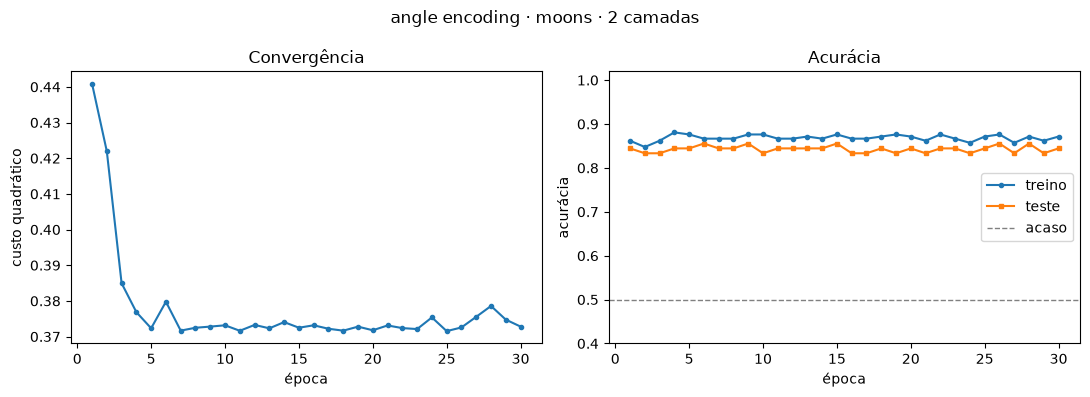

In [5]:
hist = resultado.historico

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist["epoca"], hist["custo"], marker="o", ms=3)
axes[0].set_xlabel("época"); axes[0].set_ylabel("custo quadrático")
axes[0].set_title("Convergência")

axes[1].plot(hist["epoca"], hist["acc_treino"], marker="o", ms=3, label="treino")
axes[1].plot(hist["epoca"], hist["acc_teste"], marker="s", ms=3, label="teste")
axes[1].axhline(0.5, ls="--", lw=1, color="gray", label="acaso")
axes[1].set_xlabel("época"); axes[1].set_ylabel("acurácia")
axes[1].set_ylim(0.4, 1.02); axes[1].legend()
axes[1].set_title("Acurácia")

fig.suptitle(f"{ENCODING} encoding · {DATASET} · {N_LAYERS} camadas")
fig.tight_layout()
fig.savefig(FIGS / f"02_treino_{ENCODING}_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()

## Fronteira de decisão

O que o modelo aprendeu, desenhado sobre o plano inteiro. O fundo é a saída contínua
$\langle Z_0 \rangle + b$; a linha preta é onde ela cruza zero — a fronteira.

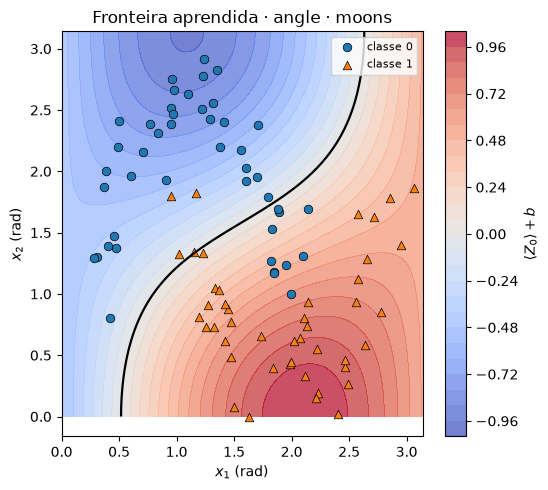

In [6]:
g = np.linspace(0, np.pi, 80)
XX, YY = np.meshgrid(g, g)
grade = np.c_[XX.ravel(), YY.ravel()]

Z = np.asarray(
    model.saida_continua(clf, resultado.weights, resultado.alpha, resultado.bias, grade), dtype=float
).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(5.6, 5))
mapa = ax.contourf(XX, YY, Z, levels=25, cmap="coolwarm", alpha=0.7, vmin=-1, vmax=1)
ax.contour(XX, YY, Z, levels=[0.0], colors="black", linewidths=1.6)

for classe, marcador in [(0, "o"), (1, "^")]:
    m = ds.y_test == classe
    ax.scatter(ds.X_test[m, 0], ds.X_test[m, 1], marker=marcador, s=38,
               edgecolor="k", linewidth=0.5, label=f"classe {classe}")

ax.set_xlabel(r"$x_1$ (rad)"); ax.set_ylabel(r"$x_2$ (rad)")
ax.set_title(f"Fronteira aprendida · {ENCODING} · {DATASET}")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(mapa, ax=ax, label=r"$\langle Z_0 \rangle + b$")
fig.tight_layout()
fig.savefig(FIGS / f"02_fronteira_{ENCODING}_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()

### O que observar

Com **`angle`** e poucas camadas, a fronteira tende a ser **suave e pouco encurvada**.
Isso não é defeito de implementação: é consequência direta da Etapa 5. A saída do
circuito é

$$f_\theta(x) = \sum_{\omega \in \Omega} c_\omega(\theta)\, e^{i\omega x},$$

e uma codificação de camada única dá acesso a um conjunto $\Omega$ pequeno de
frequências — aqui $\Omega = \{-1, 0, 1\}$. Poucas frequências, funções pouco
oscilantes, fronteiras simples.

É essa a previsão que o *data re-uploading* deve derrubar: reinserindo $x$ em $L$
blocos, $\Omega$ cresce para $\{-L, \ldots, L\}$, e fronteiras fechadas como as do
`circles` passam a ser representáveis. Rode `ENCODING = "reuploading"` com
`DATASET = "circles"` e compare com o `angle` no mesmo dataset — é o par que mais
mostra a diferença.

Com **`amplitude`**, olhe outra coisa: a fronteira sai de um modelo de 1 qubit e 6
parâmetros, e a normalização já descartou a norma de $x$. Com **`zz`**, a correlação
entre os atributos entra já na codificação, e não no ansatz.

**Troque `DATASET` e `ENCODING` na célula de parâmetros e rode de novo.**
Anote onde cada codificação falha — esses são os casos que dão sentido à comparação
da Etapa 10. O protocolo (camadas, épocas, `lr`, semente) fica **fixo** em `PADRAO`:
é por ele não variar que a diferença observada é atribuível à codificação.

Para gerar os números do Capítulo 4, use a linha de comando — não este notebook:

```bash
python -m tccqml comparar     # a grade inteira, com as mesmas sementes
python -m tccqml tabelas      # as tabelas .tex
python -m tccqml figuras      # as figuras .pdf
```

O notebook e a CLI compartilham o mesmo caminho de código, então não divergem.
Notebooks paralelos, um por codificação, divergiriam: basta uma célula rodada fora
de ordem para a comparação deixar de ser válida sem ninguém perceber.

## Registrando o resultado

A partir daqui todo experimento vira uma linha em CSV. A Etapa 10 pede tabelas
comparando codificações; construí-las lendo arquivos, e não re-treinando, é o que
mantém a análise barata e reprodutível.

In [7]:
RESULTADOS = RAIZ / "results"
RESULTADOS.mkdir(exist_ok=True)

hist.assign(**resultado.meta).to_csv(
    RESULTADOS / f"02_historico_{clf.encoding}_{ds.name}.csv", index=False
)

resumo = {**resultado.meta, "acc_treino": resultado.acc_treino, "acc_teste": resultado.acc_teste}
for k, v in resumo.items():
    print(f"{k:12s} {v}")

encoding     angle
dataset      moons
ansatz       strongly_entangling
n_qubits     2
n_layers     2
n_params_circuito 12
n_params_encoding 0
n_params     13
epocas       30
batch_size   20
lr           0.1
seed         42
acc_treino   0.8714285714285714
acc_teste    0.8444444444444444


## Próximo passo

**Etapa 9.** Com esta base congelada — mesmo ansatz, mesmo dataset, mesmo protocolo —
acrescentar as demais codificações em `embeddings.py`: amplitude, data re-uploading e
o feature map entrelaçado. Cada uma vira uma entrada no dicionário `ENCODINGS`, e este
notebook roda igual trocando uma string.

Atenção a um detalhe que já se anuncia: o amplitude encoding com 2 features usa
**1 qubit**, não 2. O ansatz precisará se adaptar ao número de qubits que a codificação
determina — o `model.build` já está escrito para isso, mas vale conferir quando chegar lá.